In [2]:
import os
print(os.getcwd())

c:\Projects\bluestock_mf_capstone\notebooks


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")

In [4]:
funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
cat = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")
holding = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [5]:
nav = nav.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'scheme_name']


In [6]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trends"
)

fig.show()

In [7]:
fig.write_image("../charts/nav_trend.png")

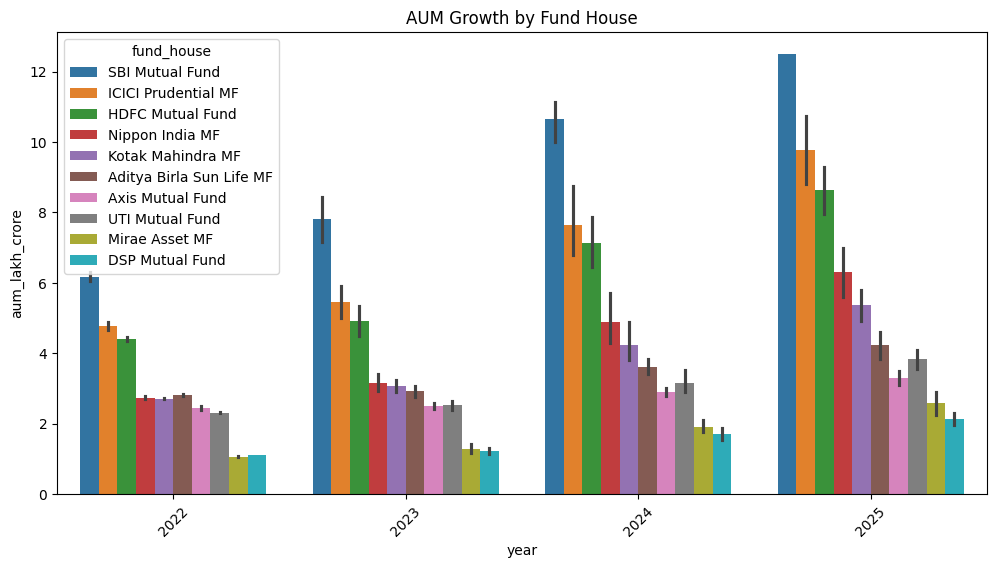

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum["year"] = pd.to_datetime(aum["date"]).dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)

plt.show()

In [11]:
plt.savefig(
    "../charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [12]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

fig.show()

In [13]:

fig.write_html("../charts/sip_trend.html")
fig.write_image("../charts/sip_trend.png")

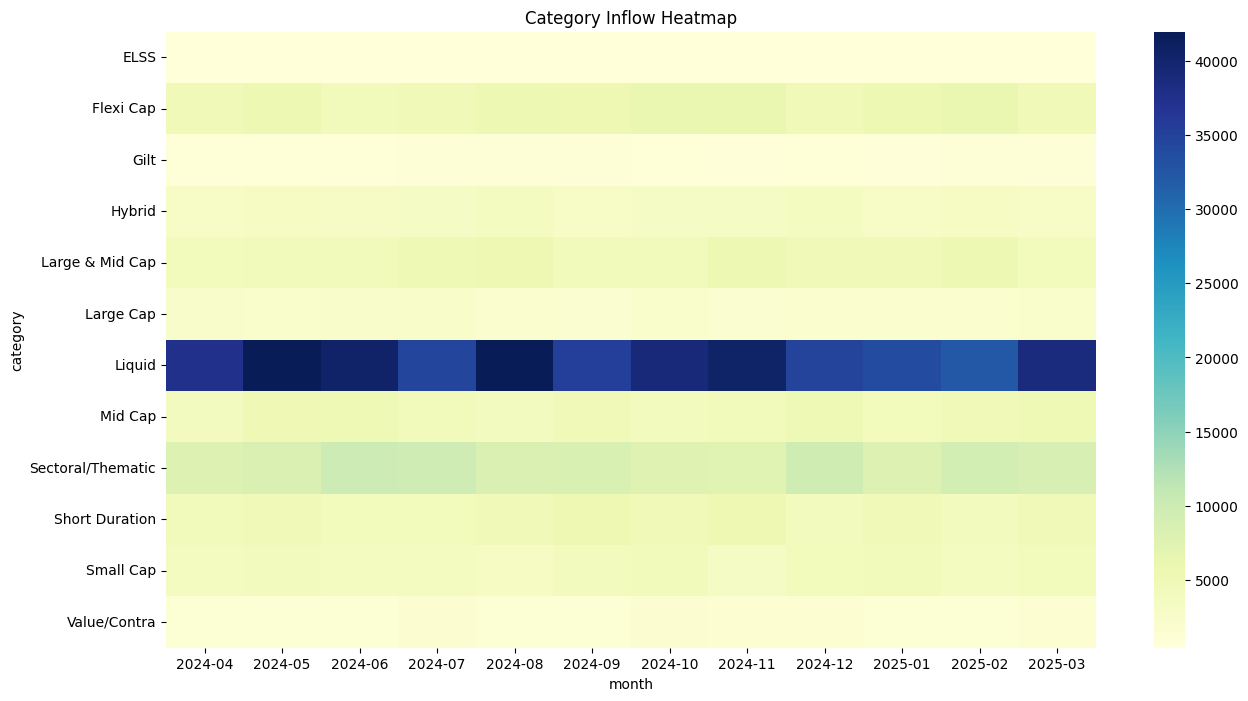

In [14]:
cat = pd.read_csv("../data/raw/05_category_inflows.csv")

pivot = cat.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

In [15]:
plt.savefig(
    "../charts/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

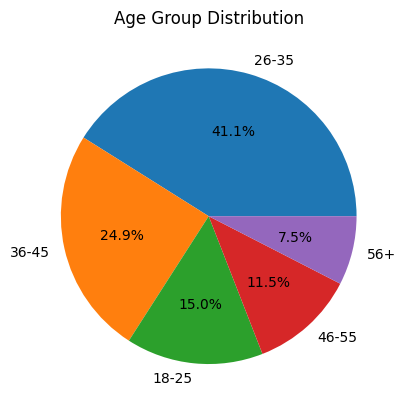

In [16]:
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")

txn["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")

plt.show()

In [17]:
plt.savefig(
    "../charts/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

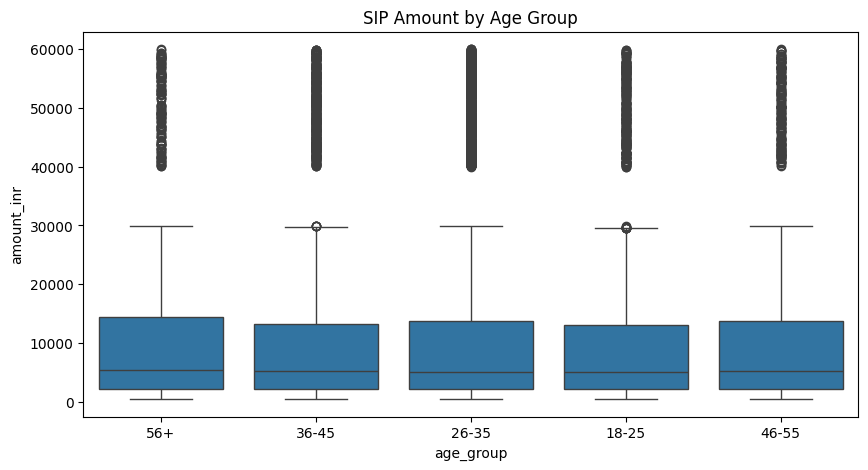

In [18]:
sip_txn = txn[
    txn["transaction_type"]=="SIP"
]

plt.figure(figsize=(10,5))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.show()

In [19]:
plt.savefig(
    "../charts/sip_boxplot_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

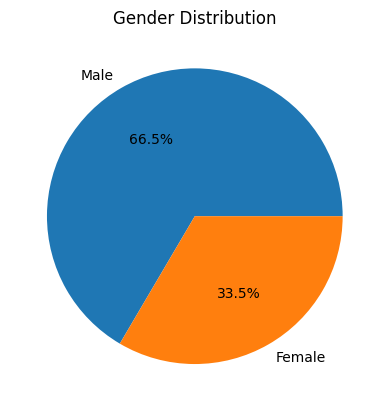

In [20]:
txn["gender"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

In [21]:
plt.savefig(
    "../charts/gender_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

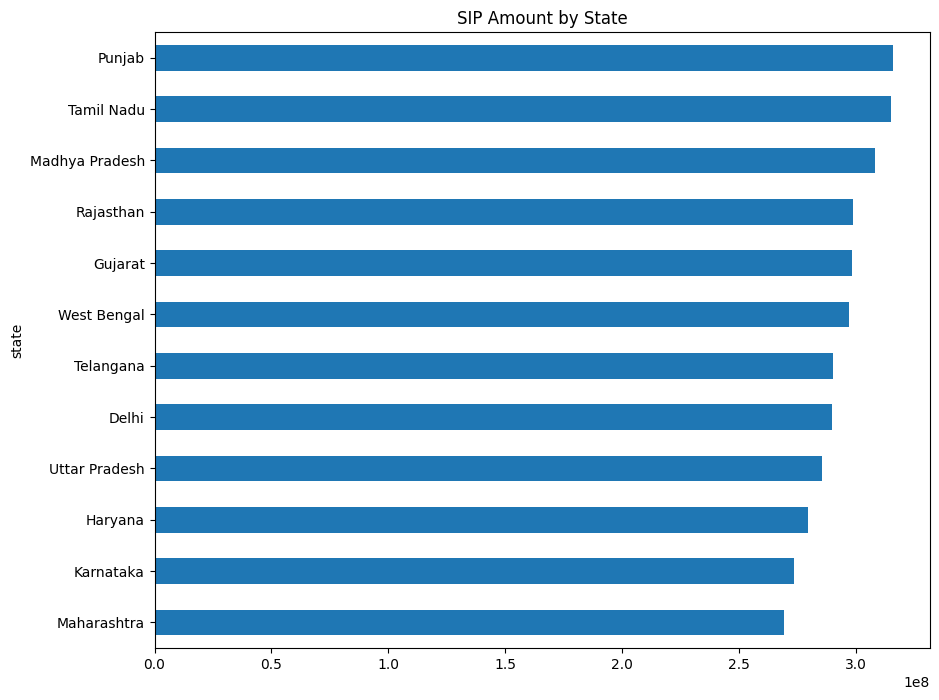

In [22]:
state_data = txn.groupby(
    "state"
)["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))

state_data.plot.barh()

plt.title("SIP Amount by State")

plt.show()

In [23]:
plt.savefig(
    "../charts/state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

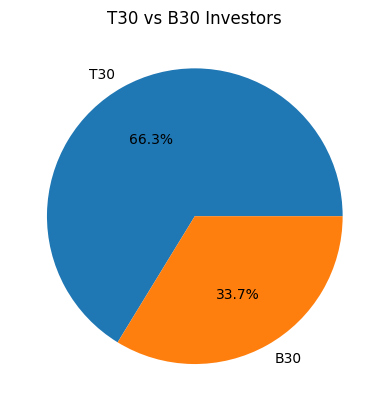

In [24]:
txn["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investors")

plt.show()

In [25]:
plt.savefig(
    "../charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

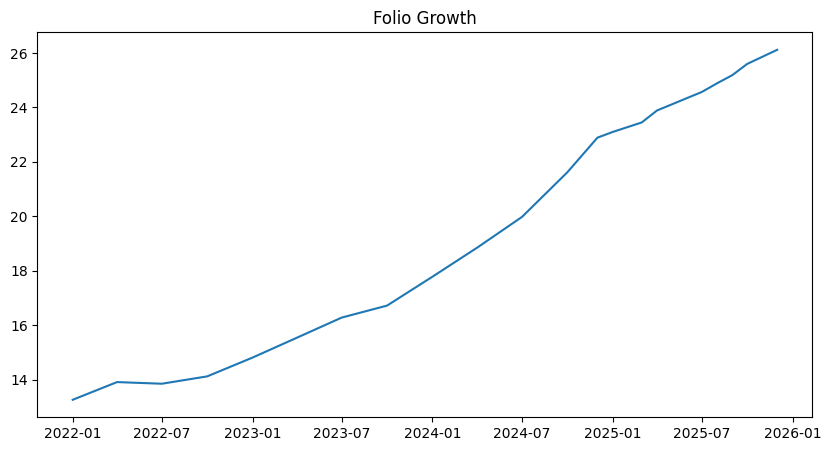

In [26]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(10,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Folio Growth")

plt.show()

In [27]:
plt.savefig(
    "../charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

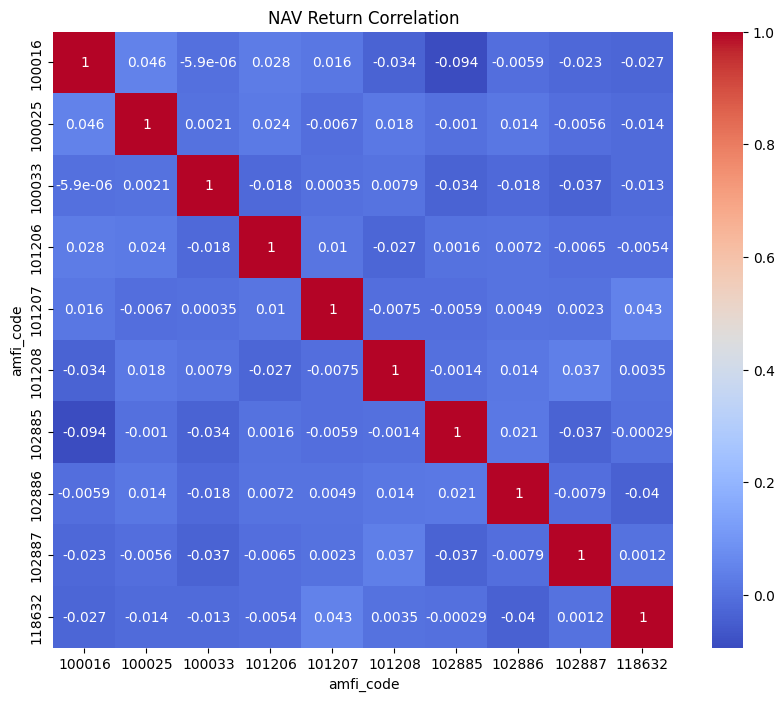

In [28]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

pivot = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

pivot = pivot.iloc[:, :10]

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation")

plt.show()

In [29]:
plt.savefig(
    "../charts/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

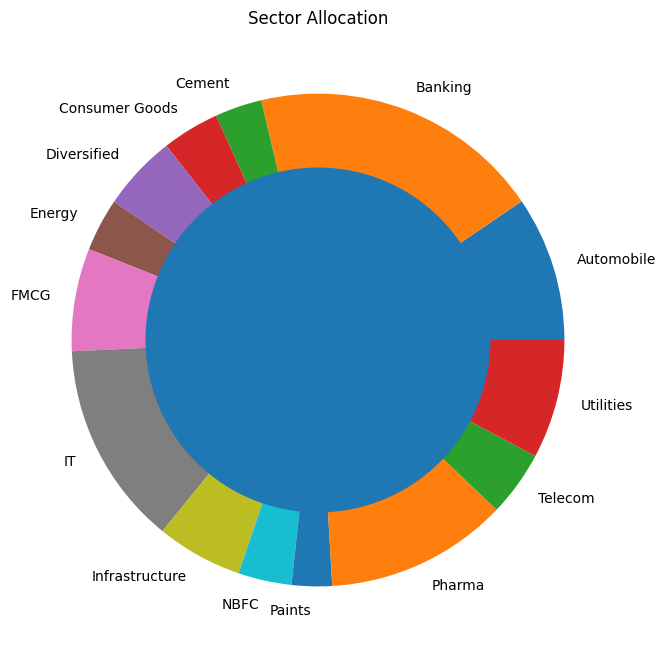

In [30]:
holding = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

sector = holding.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index
)

centre = plt.Circle((0,0),0.70)

fig = plt.gcf()

fig.gca().add_artist(centre)

plt.title("Sector Allocation")

plt.show()

In [31]:
plt.savefig(
    "../charts/sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

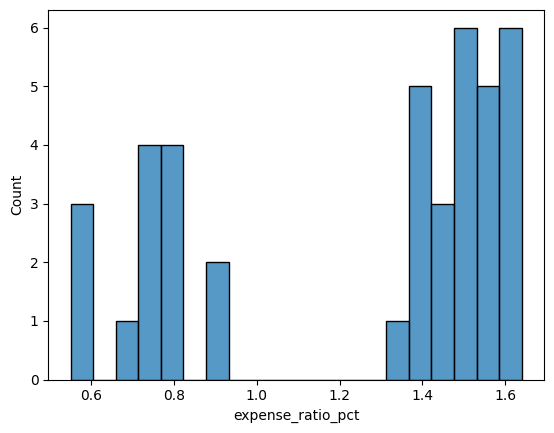

In [32]:
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")

sns.histplot(
    perf["expense_ratio_pct"],
    bins=20
)

plt.show()

In [33]:
plt.savefig(
    "../charts/expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

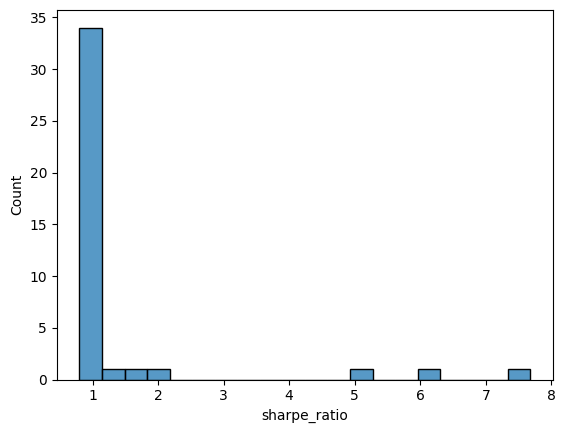

In [34]:
sns.histplot(
    perf["sharpe_ratio"],
    bins=20
)

plt.show()

In [35]:
plt.savefig(
    "../charts/sharpe_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

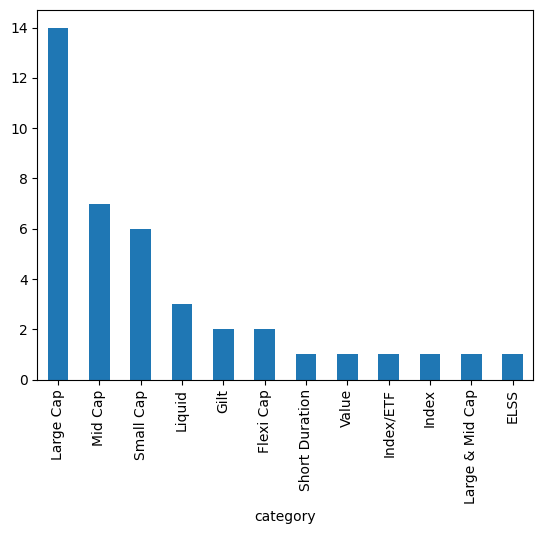

In [36]:
perf["category"].value_counts().plot.bar()

plt.show()

In [37]:
plt.savefig(
    "../charts/fund_category_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>